# Urban Air Quality Project: PM2.5 Prediction

This notebook is my data science project about PM2.5 air pollution. I use traffic data and weather data to see how well they can explain and predict PM2.5 levels.

## Research questions

1. Which variables seem most related to PM2.5?
2. Can I predict PM2.5 with regression models?
3. Can I make a simple high-risk / normal-risk classification?
4. Which model works best on this dataset?



## Introduction

I chose this topic because air quality is something that directly affects people's health, especially in big cities. I was curious to see if I could find patterns in pollution levels and understand what factors might influence them.

Also, I wanted to practice working with real-world data and apply some machine learning techniques to a problem that has practical importance.


## Data sources

I used two CSV files. One contains weather and PM2.5 values, and the other contains traffic information. Both files have an hourly `timestamp`, so I can merge them into one dataset.



## Assumptions and success criteria

This is a course project, not an official pollution warning system. I assume that the timestamps match correctly and that the variables are measured for the same hours.

For the project to be successful, I want to show a complete workflow: load the data, check it, merge it, make features, create plots, train models and explain the results.



## Related work and background

Air pollution prediction is usually done with weather variables, traffic data and sometimes more advanced data such as satellite or sensor networks. In this project I use a smaller and simpler dataset, so I focus on basic machine learning models that are easier to understand.

Linear models are useful as a baseline because they are interpretable. Random Forest models can catch more complicated patterns, but they are less transparent. Because of this I compare both types.



## Modeling Approach

After exploring the data, I compare several regression models instead of selecting one manually. Linear Regression, Ridge, Lasso and Random Forest are trained on the same train/test split. The final regression model is selected automatically using the lowest RMSE on the held-out test set.

This is important because Random Forest is not always the best option: if the relationship in the dataset is mostly linear, Linear or Ridge regression can perform better and remain easier to interpret.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

# Locate project root robustly: works when launched from the project root,
# the notebooks/ subfolder, or from VS Code (which sets __vsc_ipynb_file__).
if "__vsc_ipynb_file__" in globals():
    PROJECT_ROOT = Path(globals()["__vsc_ipynb_file__"]).resolve().parent.parent
elif Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
elif (Path.cwd() / "requirements.txt").exists():
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

# Add src/ to path so analysis_utils can be imported directly
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from analysis_utils import (
    validate_timestamp_key,
    check_hourly_continuity,
    add_time_features,
    make_pm25_risk_label,
    sorted_target_correlations,
)

weather = pd.read_csv(DATA_DIR / "weather_air_quality.csv", parse_dates=["timestamp"])
traffic = pd.read_csv(DATA_DIR / "traffic_counts.csv", parse_dates=["timestamp"])

display(weather.head())
display(traffic.head())
print(weather.shape, traffic.shape)


ModuleNotFoundError: No module named 'analysis_utils'

## Observations

While exploring the data, I noticed that the pollution values change over time rather than across different groups. There are clear fluctuations, which suggests that pollution levels are not constant and may depend on external factors like time or conditions.

I also observed that most values stay within a certain range, with occasional spikes. These spikes might represent unusual events or higher pollution periods, which are important for the model to capture.


## Data validation, merge, and feature engineering

First I check if the timestamp column is usable. Then I merge the two datasets and add a few simple time features.



In [ ]:
# quick check of timestamps in both files
print("Weather:", validate_timestamp_key(weather))
print("Traffic:", validate_timestamp_key(traffic))

# merge only the hours that exist in both files
df = pd.merge(weather, traffic, on="timestamp", how="inner")
df = df.sort_values("timestamp").reset_index(drop=True)

# add_time_features adds hour, day_of_week, and is_weekend from the timestamp column
df = add_time_features(df)

# --- Hourly continuity check ---
# Verifies that every expected hour is present (no skipped hours in the merged series).
cont = check_hourly_continuity(df)
print(f"\nHourly continuity: {cont['missing_hours']} gap(s) detected in {cont['rows']} rows")
if cont["missing_hours"] > 0:
    print("  First gaps at:", cont["gap_timestamps"][:5])

# Threshold set to 25 µg/m³ for this educational project.
# Note: this value is used as a simple hourly proxy for labelling high-risk periods.
# Official PM2.5 standards (e.g. WHO IT-2: 15 µg/m³) are defined as 24-hour averages,
# not per-hour limits, so this threshold should NOT be interpreted as a regulatory limit.
PM25_RISK_THRESHOLD = 25
df = make_pm25_risk_label(df, threshold=PM25_RISK_THRESHOLD)

# --- Lag feature: previous hour's PM2.5 ---
# PM2.5 is strongly autocorrelated: the level at hour t is a good predictor of hour t+1.
# The first row becomes NaN after shifting and is dropped to keep the data clean.
df["pm25_lag_1h"] = df["pm25_ugm3"].shift(1)
df = df.dropna(subset=["pm25_lag_1h"]).reset_index(drop=True)

print("\nShape after adding pm25_lag_1h (first row dropped):", df.shape)
display(df.isna().sum())
display(df.describe())
print("High-risk share:", round(df["high_pm25_risk"].mean(), 3))


Weather: {'rows': 2160, 'missing_timestamps': 0, 'duplicate_timestamps': 0}
Traffic: {'rows': 2160, 'missing_timestamps': 0, 'duplicate_timestamps': 0}

Hourly continuity: 0 gap(s) detected in 2160 rows

Shape after adding pm25_lag_1h (first row dropped): (2159, 13)


timestamp           0
temperature_c       0
humidity_pct        0
wind_speed_ms       0
pm25_ugm3           0
traffic_volume      0
avg_speed_kmh       0
congestion_index    0
hour                0
day_of_week         0
is_weekend          0
high_pm25_risk      0
pm25_lag_1h         0
dtype: int64

,timestamp,temperature_c,humidity_pct,wind_speed_ms,pm25_ugm3,traffic_volume,avg_speed_kmh,congestion_index,hour,day_of_week,is_weekend,high_pm25_risk,pm25_lag_1h
count,2159,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000
mean,2026-02-15 00:00:00,9.443446,54.218666,3.055660,17.796572,447.431681,36.431172,0.310059,11.505327,3.011116,0.289023,0.115794,17.795484
min,2026-01-01 01:00:00,-4.900000,25.000000,1.340000,3.000000,80.000000,14.100000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,2026-01-23 12:30:00,5.800000,43.700000,2.290000,13.590000,344.000000,32.100000,0.144500,6.000000,1.000000,0.000000,0.000000,13.590000
50%,2026-02-15 00:00:00,9.300000,54.200000,3.070000,17.350000,429.000000,36.700000,0.275000,12.000000,3.000000,0.000000,0.000000,17.340000
75%,2026-03-09 11:30:00,13.200000,65.000000,3.650000,21.635000,529.000000,40.700000,0.441000,17.500000,5.000000,1.000000,0.000000,21.635000
max,2026-03-31 23:00:00,21.600000,98.000000,7.380000,37.080000,924.000000,54.600000,1.000000,23.000000,6.000000,1.000000,1.000000,37.080000
std,NaN,5.149537,13.601969,0.943408,5.820658,146.927462,6.455080,0.221828,6.920965,2.009216,0.453413,0.320052,5.820723


High-risk share: 0.116


### Validation notes

This step checks missing timestamps, duplicate timestamps, missing values after merging, and hourly continuity (no skipped hours). I included it because problems here could affect all the modelling later.


In [ ]:
# small validation table
vk_weather = validate_timestamp_key(weather)
vk_traffic = validate_timestamp_key(traffic)
vk_merged  = validate_timestamp_key(df)

cont_weather = check_hourly_continuity(weather)
cont_traffic = check_hourly_continuity(traffic)
cont_merged  = check_hourly_continuity(df)

validation_report = pd.DataFrame({
    "dataset": ["weather_air_quality", "traffic_counts", "merged"],
    "rows": [vk_weather["rows"], vk_traffic["rows"], vk_merged["rows"]],
    "duplicate_timestamps": [
        vk_weather["duplicate_timestamps"],
        vk_traffic["duplicate_timestamps"],
        vk_merged["duplicate_timestamps"],
    ],
    "hourly_gaps": [
        cont_weather["missing_hours"],
        cont_traffic["missing_hours"],
        cont_merged["missing_hours"],
    ],
    "total_missing_values": [
        weather.isna().sum().sum(),
        traffic.isna().sum().sum(),
        df.isna().sum().sum(),
    ],
})

display(validation_report)


,dataset,rows,duplicate_timestamps,hourly_gaps,total_missing_values
0,weather_air_quality,2160,0,0,0
1,traffic_counts,2160,0,0,0
2,merged,2159,0,0,0


## Exploratory data analysis

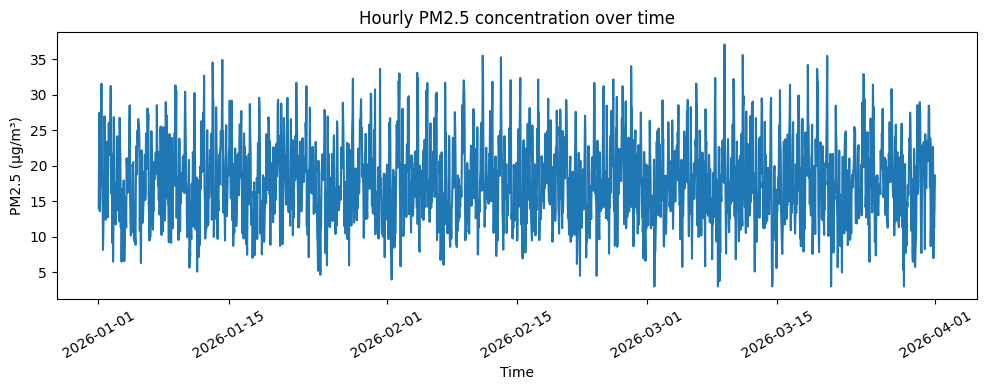

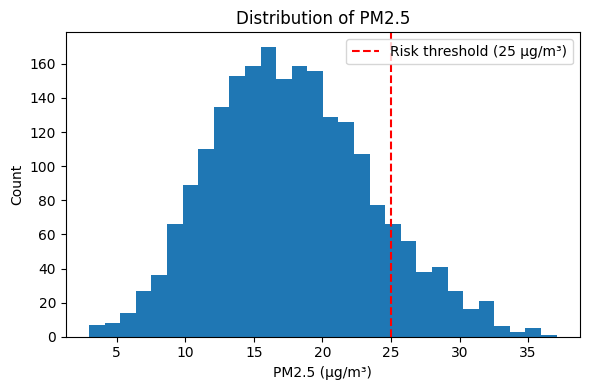

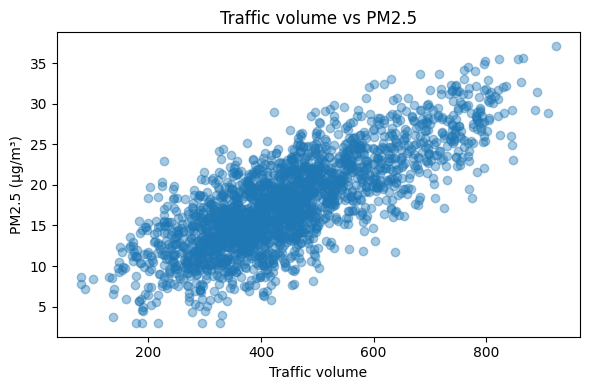

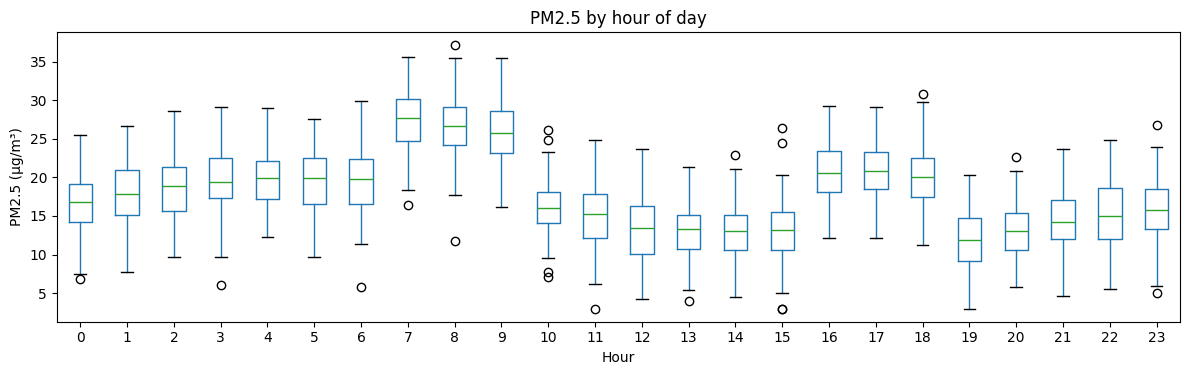

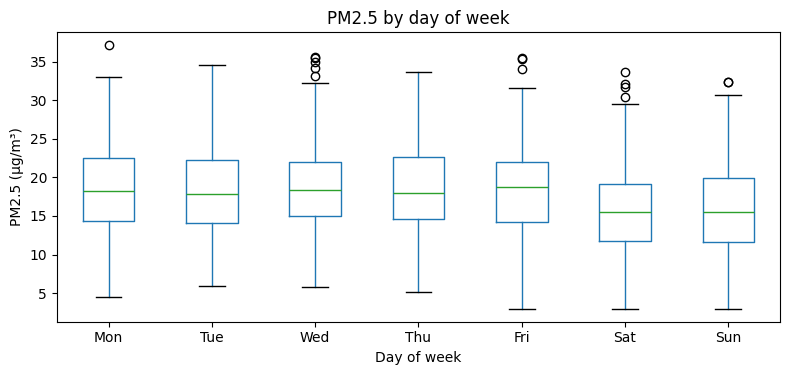

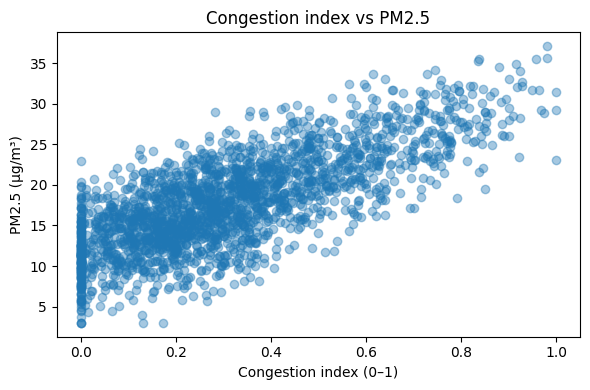

is_weekend
Weekday    18.604710
Weekend    15.808606
Name: pm25_ugm3, dtype: float64


In [ ]:
# --- Time series overview ---
plt.figure(figsize=(10, 4))
plt.plot(df["timestamp"], df["pm25_ugm3"])
plt.title("Hourly PM2.5 concentration over time")
plt.xlabel("Time"); plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

# --- Distribution of PM2.5 with risk threshold marker ---
plt.figure(figsize=(6, 4))
plt.hist(df["pm25_ugm3"], bins=30)
plt.axvline(PM25_RISK_THRESHOLD, color="red", linestyle="--",
            label=f"Risk threshold ({PM25_RISK_THRESHOLD} µg/m³)")
plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5 (µg/m³)"); plt.ylabel("Count")
plt.legend(); plt.tight_layout(); plt.show()

# --- Scatter: traffic volume vs PM2.5 ---
plt.figure(figsize=(6, 4))
plt.scatter(df["traffic_volume"], df["pm25_ugm3"], alpha=0.4)
plt.title("Traffic volume vs PM2.5")
plt.xlabel("Traffic volume"); plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout(); plt.show()

# --- Boxplot by hour of day – reveals intra-day pollution patterns ---
plt.figure(figsize=(12, 4))
df.boxplot(column="pm25_ugm3", by="hour", ax=plt.gca(), grid=False)
plt.suptitle("")
plt.title("PM2.5 by hour of day")
plt.xlabel("Hour"); plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout(); plt.show()

# --- Boxplot by day of week (0=Monday ... 6=Sunday) ---
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
plt.figure(figsize=(8, 4))
df.boxplot(column="pm25_ugm3", by="day_of_week", ax=plt.gca(), grid=False)
plt.suptitle("")
plt.title("PM2.5 by day of week")
plt.gca().set_xticklabels(day_labels)
plt.xlabel("Day of week"); plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout(); plt.show()

# --- Scatter: congestion index vs PM2.5 ---
# congestion_index is a direct proxy for traffic density; important to visualise separately
plt.figure(figsize=(6, 4))
plt.scatter(df["congestion_index"], df["pm25_ugm3"], alpha=0.4)
plt.title("Congestion index vs PM2.5")
plt.xlabel("Congestion index (0–1)"); plt.ylabel("PM2.5 (µg/m³)")
plt.tight_layout(); plt.show()

# --- Mean PM2.5 by weekday vs weekend ---
print(df.groupby("is_weekend")["pm25_ugm3"].mean().rename({0: "Weekday", 1: "Weekend"}))


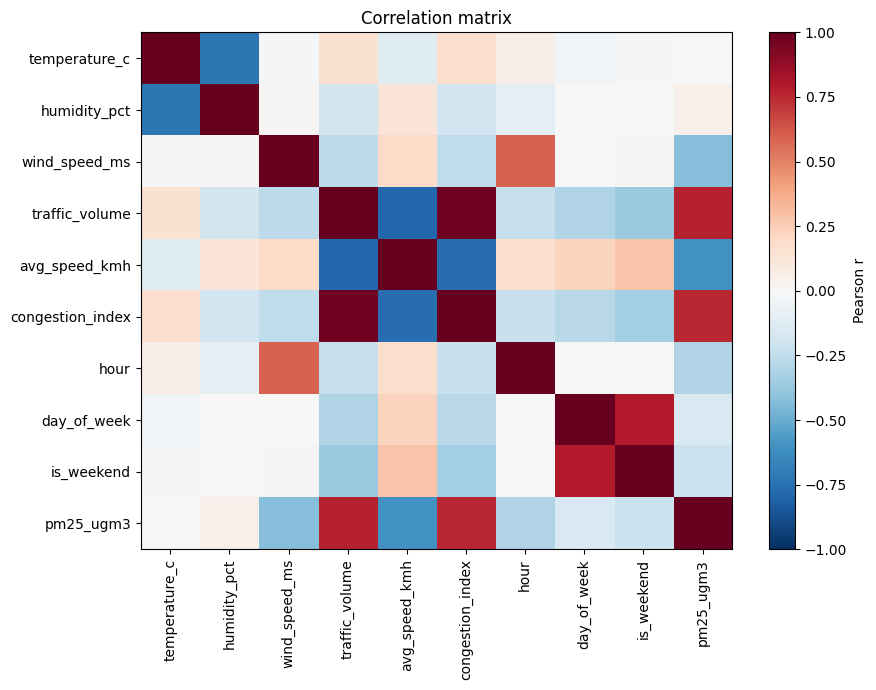

pm25_ugm3           1.000000
traffic_volume      0.771444
congestion_index    0.753405
humidity_pct        0.046992
temperature_c       0.005773
day_of_week        -0.155637
is_weekend         -0.217809
hour               -0.302238
wind_speed_ms      -0.427074
avg_speed_kmh      -0.602144
Name: pm25_ugm3, dtype: float64

In [ ]:
# Include engineered time features and lag to see correlations with PM2.5
numeric_cols = [
    "temperature_c", "humidity_pct", "wind_speed_ms",
    "traffic_volume", "avg_speed_kmh", "congestion_index",
    "hour", "day_of_week", "is_weekend", "pm25_lag_1h", "pm25_ugm3"
]
corr = df[numeric_cols].corr()

# Heatmap via imshow – no seaborn dependency
plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto", vmin=-1, vmax=1, cmap="RdBu_r")
plt.colorbar(label="Pearson r")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation matrix")
plt.tight_layout(); plt.show()

# sorted_target_correlations returns PM2.5 correlations sorted descending
display(sorted_target_correlations(df, numeric_cols, "pm25_ugm3"))


### Exploratory interpretation

The plots are used to get a first feeling for the data before modelling. I look at the PM2.5 distribution, changes over time and relationships with traffic and weather variables. Some relationships are not perfectly linear, which is one reason why I later test Random Forest models too.



## Mathematical background

### Pearson correlation

Correlation shows how two variables move together in a straight line. If the value is close to 1, they increase together. If the value is close to -1, one increases when the other decreases. If the value is close to 0, there is no strong linear relationship.

### Linear regression

Linear regression tries to predict PM2.5 as a weighted sum of the input variables. It is easy to explain, but it may miss non-linear patterns.

### Ridge and Lasso

Ridge and Lasso are versions of linear regression with regularization. I used them to compare against normal linear regression and to reduce overfitting.

### Random Forest

Random Forest builds many decision trees and averages their predictions. It can model more complex relationships, but the result is harder to explain than a simple regression equation.

### Classification

The classification task uses the same chronological split as the regression task, so the test set represents future observations rather than randomly selected rows.\n

For the high-risk task I used accuracy, precision, recall, F1-score, ROC-AUC and the confusion matrix. These are useful because accuracy alone can be misleading if the classes are not balanced.


## Regression task: predicting PM2.5

Here I train a few regression models and compare their test results. The target variable is `pm25_ugm3`.



In [ ]:
# --- Feature / target split ---
features = [
    "temperature_c", "humidity_pct", "wind_speed_ms",
    "traffic_volume", "avg_speed_kmh", "congestion_index",
    "hour", "day_of_week", "is_weekend",
    "pm25_lag_1h",   # previous hour's PM2.5 — strong autocorrelation predictor
]
target = "pm25_ugm3"

# The rows were already sorted by timestamp after merging.
# Because this is time-based hourly data, the holdout set must be later in time
# than the training set. This avoids leaking future patterns into the model.
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

X = df[features]
y = df[target]

print("Chronological split")
print(f"Train period: {train_df['timestamp'].min()} to {train_df['timestamp'].max()} ({len(train_df)} rows)")
print(f"Test period:  {test_df['timestamp'].min()} to {test_df['timestamp'].max()} ({len(test_df)} rows)")

# --- Define models ---
# Pipeline standardises features before linear models (required for Ridge/Lasso)
lin_reg = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
ridge_reg = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])
lasso_reg = Pipeline([("scaler", StandardScaler()), ("model", Lasso(alpha=0.5, max_iter=5000))])

# Random Forest does not require scaling; min_samples_leaf=2 reduces overfitting
rf_reg = RandomForestRegressor(n_estimators=120, random_state=42, min_samples_leaf=2)

models = {
    "Linear Regression (OLS)": lin_reg,
    "Ridge Regression (L2)": ridge_reg,
    "Lasso Regression (L1)": lasso_reg,
    "Random Forest Regressor": rf_reg,
}

# --- Train and evaluate on the future holdout test set ---
regression_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    regression_results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred),
    })

regression_results = pd.DataFrame(regression_results).sort_values("RMSE")
display(regression_results)


Chronological split
Train period: 2026-01-01 01:00:00 to 2026-03-13 23:00:00 (1727 rows)
Test period:  2026-03-14 00:00:00 to 2026-03-31 23:00:00 (432 rows)


,model,MAE,MSE,RMSE,R2
0,Linear Regression (OLS),2.531241,10.315095,3.211712,0.715369
1,Ridge Regression (L2),2.531879,10.320646,3.212576,0.715216
3,Random Forest Regressor,2.702627,11.395045,3.375655,0.685569
2,Lasso Regression (L1),2.672568,11.528446,3.395357,0.681888


In [ ]:
# Baseline: always predict the training mean (dumb predictor)
mean_pred = np.full(len(y_test), y_train.mean())
baseline_rmse = mean_squared_error(y_test, mean_pred) ** 0.5
baseline_mae  = mean_absolute_error(y_test, mean_pred)
baseline_r2   = r2_score(y_test, mean_pred)

print("Baseline (mean predictor):")
print(f"  MAE  = {baseline_mae:.3f}")
print(f"  RMSE = {baseline_rmse:.3f}")
print(f"  R²   = {baseline_r2:.3f}")
print()
print("Best ML model for comparison:")
best_row = regression_results.iloc[0]
print(f"  {best_row['model']}: RMSE = {best_row['RMSE']:.3f}, R² = {best_row['R2']:.3f}")


Baseline (mean predictor):
  MAE  = 4.891
  RMSE = 6.025
  R²   = -0.002

Best ML model for comparison:
  Linear Regression (OLS): RMSE = 3.212, R² = 0.715


## Regression validation with cross-validation

In [ ]:
# Time-aware cross-validation keeps the order of observations.
# Each fold trains on earlier rows and validates on later rows.
ts_cv = TimeSeriesSplit(n_splits=5)

cv_results = []
for name, model in models.items():
    rmse_scores = -cross_val_score(model, X, y, scoring="neg_root_mean_squared_error", cv=ts_cv)
    r2_scores = cross_val_score(model, X, y, scoring="r2", cv=ts_cv)
    cv_results.append({
        "model": name,
        "TimeSeriesCV_RMSE_mean": rmse_scores.mean(),
        "TimeSeriesCV_RMSE_std": rmse_scores.std(),
        "TimeSeriesCV_R2_mean": r2_scores.mean(),
        "TimeSeriesCV_R2_std": r2_scores.std()
    })

display(pd.DataFrame(cv_results).sort_values("TimeSeriesCV_RMSE_mean"))


,model,TimeSeriesCV_RMSE_mean,TimeSeriesCV_RMSE_std,TimeSeriesCV_R2_mean,TimeSeriesCV_R2_std
1,Ridge Regression (L2),3.265344,0.048056,0.682897,0.021855
0,Linear Regression (OLS),3.265450,0.048313,0.682867,0.022015
2,Lasso Regression (L1),3.383561,0.090580,0.660163,0.014399
3,Random Forest Regressor,3.415550,0.043519,0.652877,0.026122


### Regression model choice

I compare the models using MAE, RMSE and R². The model with the lowest RMSE is selected for the prediction/residual plots. For interpretation, I show coefficients for linear models and feature importances only if the selected model is Random Forest.


Best regression model based on RMSE: Linear Regression (OLS)


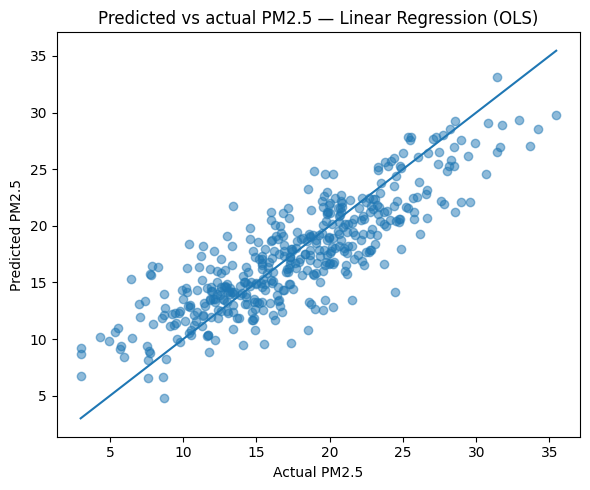

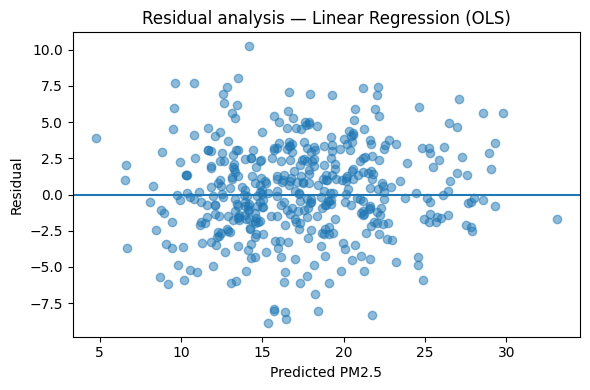

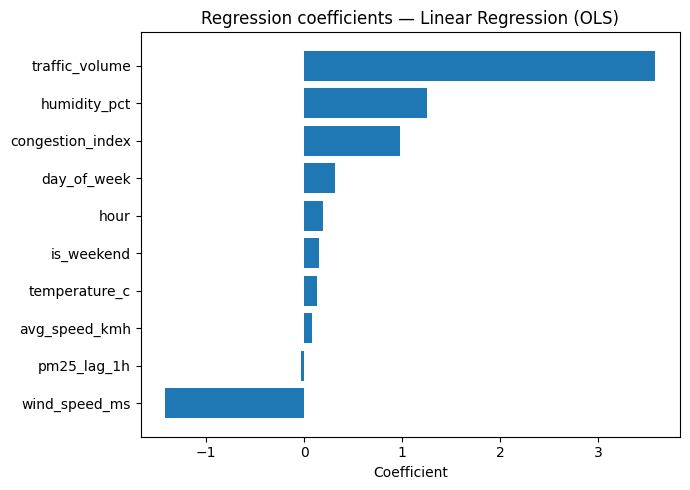

traffic_volume      3.583118
wind_speed_ms      -1.416808
humidity_pct        1.249290
congestion_index    0.975412
day_of_week         0.313442
hour                0.190669
is_weekend          0.150562
temperature_c       0.130977
avg_speed_kmh       0.080821
pm25_lag_1h        -0.036654
dtype: float64

In [ ]:
# Select the best regression model using the evaluation table above.
# Lower RMSE is better, so this avoids hard-coding Random Forest as the best model.
best_model_name = regression_results.sort_values("RMSE").iloc[0]["model"]
best_reg = models[best_model_name]

reg_pred = best_reg.predict(X_test)
print(f"Best regression model based on RMSE: {best_model_name}")

plt.figure(figsize=(6, 5))
plt.scatter(y_test, reg_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title(f"Predicted vs actual PM2.5 — {best_model_name}")
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.tight_layout()
plt.show()

residuals = y_test - reg_pred
plt.figure(figsize=(6, 4))
plt.scatter(reg_pred, residuals, alpha=0.5)
plt.axhline(0)
plt.title(f"Residual analysis — {best_model_name}")
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

# Interpret the selected model safely.
# Pipelines store the trained estimator in the "model" step.
if best_model_name in ["Linear Regression (OLS)", "Ridge Regression (L2)", "Lasso Regression (L1)"]:
    final_estimator = best_reg.named_steps["model"]
    coefficients = pd.Series(final_estimator.coef_, index=features).sort_values(ascending=True)

    plt.figure(figsize=(7, 5))
    plt.barh(coefficients.index, coefficients.values)
    plt.title(f"Regression coefficients — {best_model_name}")
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

    display(coefficients.reindex(coefficients.abs().sort_values(ascending=False).index))

elif hasattr(best_reg, "feature_importances_"):
    importances = pd.Series(best_reg.feature_importances_, index=features).sort_values(ascending=True)

    plt.figure(figsize=(7, 5))
    plt.barh(importances.index, importances.values)
    plt.title(f"Feature importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    display(importances.sort_values(ascending=False))
else:
    print("No direct coefficient or feature-importance output is available for this model.")



## Classification task: high PM2.5 risk

The classification task uses the same chronological split as the regression task, so the test set represents future observations rather than randomly selected rows.

Now I turn PM2.5 into a binary target. Hours above the selected threshold are marked as higher risk.


### Why classification is useful

Regression predicts the exact PM2.5 value, but sometimes a simple warning label is easier to use. The classification model answers a simpler question: is this hour likely to be high risk or not?

The risk threshold is set to **25 µg/m³** as an educational hourly proxy. Official standards such as the WHO IT-2 guideline (15 µg/m³) are defined as 24-hour averages, not per-hour limits, so this threshold should not be treated as a regulatory value — it is used here solely to create a binary high-risk label for the classification task.


In [ ]:
# Chronological classification split: train on earlier hours, test on later hours.
# This matches the forecasting-style setup used for regression.
X_train_c = train_df[features]
X_test_c = test_df[features]
y_train_c = train_df["high_pm25_risk"]
y_test_c = test_df["high_pm25_risk"]

print("Classification label balance")
print("Train positive share:", round(y_train_c.mean(), 3))
print("Test positive share: ", round(y_test_c.mean(), 3))

# class_weight="balanced" corrects for class imbalance automatically
log_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

rf_clf = RandomForestClassifier(n_estimators=120, random_state=42,
                                 class_weight="balanced", min_samples_leaf=2)

classifiers = {
    "Logistic Regression": log_clf,
    "Random Forest Classifier": rf_clf,
}

classification_results = []
for name, model in classifiers.items():
    model.fit(X_train_c, y_train_c)
    pred = model.predict(X_test_c)
    classification_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test_c, pred),
        "precision": precision_score(y_test_c, pred, zero_division=0),
        "recall": recall_score(y_test_c, pred, zero_division=0),
        "f1": f1_score(y_test_c, pred, zero_division=0),
    })

display(pd.DataFrame(classification_results).sort_values("f1", ascending=False))


Classification label balance
Train positive share: 0.118
Test positive share:  0.109


,model,accuracy,precision,recall,f1
1,Random Forest Classifier,0.932870,0.725000,0.617021,0.666667
0,Logistic Regression,0.872685,0.455556,0.872340,0.598540


In [ ]:
# Baseline: always predict the majority class from the training set
majority_class = int(y_train_c.mode()[0])
baseline_cls_pred = np.full(len(y_test_c), majority_class)

print(f"Baseline (majority class = {majority_class}):")
print(f"  Accuracy  = {accuracy_score(y_test_c, baseline_cls_pred):.3f}")
print(f"  Precision = {precision_score(y_test_c, baseline_cls_pred, zero_division=0):.3f}")
print(f"  Recall    = {recall_score(y_test_c, baseline_cls_pred, zero_division=0):.3f}")
print(f"  F1        = {f1_score(y_test_c, baseline_cls_pred, zero_division=0):.3f}")
print()
print("Best ML classifier for comparison:")
best_cls_row = pd.DataFrame(classification_results).sort_values("f1", ascending=False).iloc[0]
print(f"  {best_cls_row['model']}: F1 = {best_cls_row['f1']:.3f}, Recall = {best_cls_row['recall']:.3f}")


Baseline (majority class = 0):
  Accuracy  = 0.891
  Precision = 0.000
  Recall    = 0.000
  F1        = 0.000

Best ML classifier for comparison:
  Random Forest Classifier: F1 = 0.667, Recall = 0.617


## Hyperparameter tuning

I tuned the Random Forest classifier with GridSearchCV to find better parameters without testing too many combinations manually.

In [ ]:
param_grid = {
    "n_estimators": [80, 120],
    "max_depth": [None, 10],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt"]
}

# TimeSeriesSplit is used here too, so hyperparameter tuning does not mix
# future observations into earlier training folds.
cv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train_c, y_train_c)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", round(grid.best_score_, 4))

best_cls = grid.best_estimator_
cls_pred = best_cls.predict(X_test_c)

print(classification_report(y_test_c, cls_pred, target_names=["normal", "high-risk"], zero_division=0))


Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 80}
Best CV F1: 0.6961
              precision    recall  f1-score   support

      normal       0.96      0.96      0.96       385
   high-risk       0.67      0.68      0.67        47

    accuracy                           0.93       432
   macro avg       0.81      0.82      0.82       432
weighted avg       0.93      0.93      0.93       432



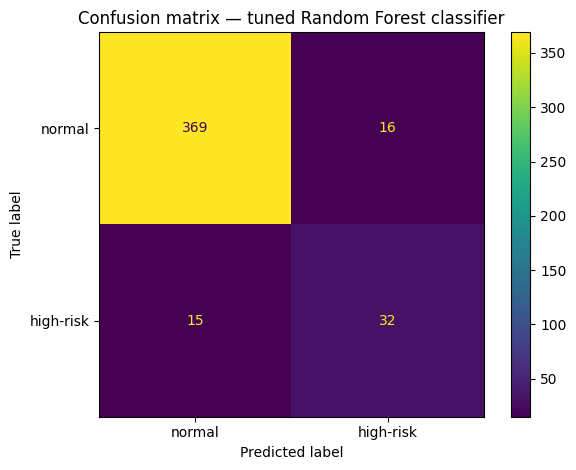

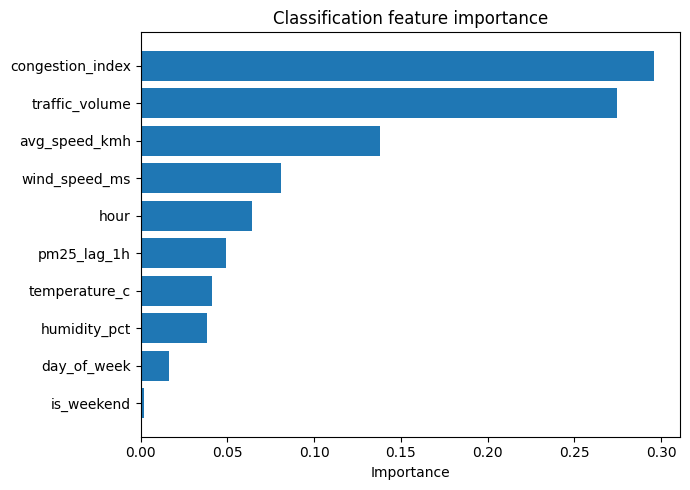

congestion_index    0.296033
traffic_volume      0.274261
avg_speed_kmh       0.138053
wind_speed_ms       0.081006
hour                0.064360
pm25_lag_1h         0.048991
temperature_c       0.041179
humidity_pct        0.038022
day_of_week         0.016472
is_weekend          0.001622
dtype: float64

In [ ]:
cm = confusion_matrix(y_test_c, cls_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["normal", "high-risk"])
disp.plot()
plt.title("Confusion matrix — tuned Random Forest classifier")
plt.tight_layout()
plt.show()

cls_importances = pd.Series(best_cls.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(7, 5))
plt.barh(cls_importances.index, cls_importances.values)
plt.title("Classification feature importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(cls_importances.sort_values(ascending=False))


## ROC curve and AUC

The ROC curve shows the trade-off between true positives and false positives. A higher AUC generally means the classifier separates the two classes better.



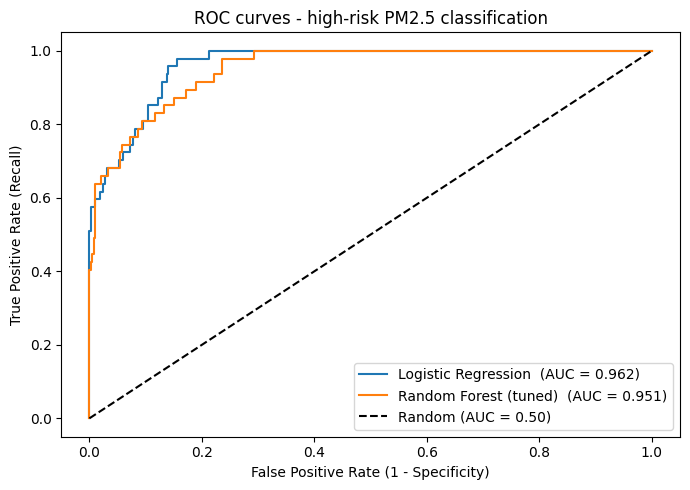

In [ ]:
plt.figure(figsize=(7, 5))

# Plot ROC for each classifier that supports predict_proba
for name, model in [("Logistic Regression", log_clf), ("Random Forest (tuned)", best_cls)]:
    # predict_proba returns [P(class=0), P(class=1)] – take column 1 for the positive class
    proba = model.predict_proba(X_test_c)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_c, proba)
    auc = roc_auc_score(y_test_c, proba)
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})")

# Diagonal reference line = random classifier (AUC = 0.5)
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.50)")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC curves - high-risk PM2.5 classification")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Precision-Recall curve

The Precision-Recall curve is also useful for risk detection, because it shows how many predicted high-risk cases are correct and how many real high-risk cases are found.



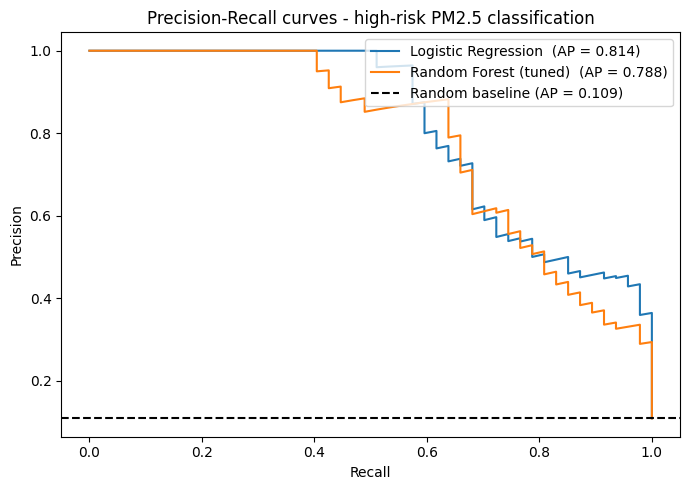

In [ ]:
plt.figure(figsize=(7, 5))

for name, model in [("Logistic Regression", log_clf), ("Random Forest (tuned)", best_cls)]:
    # predict_proba[:,1] gives the probability of the positive (high-risk) class
    proba = model.predict_proba(X_test_c)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test_c, proba)
    ap = average_precision_score(y_test_c, proba)
    plt.plot(recall, precision, label=f"{name}  (AP = {ap:.3f})")

# Baseline: a random classifier matches the positive class prevalence
baseline = y_test_c.mean()
plt.axhline(baseline, linestyle="--", color="k", label=f"Random baseline (AP = {baseline:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall curves - high-risk PM2.5 classification")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [ ]:
# ── Unified classification summary ───────────────────────────────────────────
# Single reference point for all classification metrics cited elsewhere in the notebook.
# All numbers below refer to the tuned Random Forest evaluated on the chronological test set.

cls_f1             = f1_score(y_test_c, cls_pred, zero_division=0)
cls_proba_rf       = best_cls.predict_proba(X_test_c)[:, 1]
cls_auc            = roc_auc_score(y_test_c, cls_proba_rf)
cls_threshold      = PM25_RISK_THRESHOLD
cls_positive_share = round(y_test_c.mean(), 3)

print("━" * 58)
print("Classification summary — tuned Random Forest (test set)")
print("━" * 58)
print(f"  PM2.5 risk threshold:   {cls_threshold} µg/m³  [educational hourly proxy]")
print(f"  Positive share (test):  {cls_positive_share:.1%}")
print(f"  F1  (high-risk class):  {cls_f1:.3f}")
print(f"  ROC-AUC:                {cls_auc:.3f}")
print("━" * 58)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Classification summary — tuned Random Forest (test set)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PM2.5 risk threshold:   25 µg/m³  [educational hourly proxy]
  Positive share (test):  10.9%
  F1  (high-risk class):  0.674
  ROC-AUC:                0.951
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


## Lag feature comparison

`pm25_lag_1h` captures the previous hour's PM2.5 concentration. Because air pollution levels are
strongly autocorrelated (a polluted hour is likely to be followed by another polluted hour), this
feature is expected to be one of the strongest predictors.

The table below compares the tuned Random Forest with and without `pm25_lag_1h` so the contribution
of the lag feature is explicit.


In [ ]:
# --- Retrain tuned RF without the lag feature for an apples-to-apples comparison ---
features_no_lag = [f for f in features if f != "pm25_lag_1h"]

rf_no_lag = RandomForestClassifier(
    **grid.best_params_, random_state=42, class_weight="balanced"
)
rf_no_lag.fit(X_train_c[features_no_lag], y_train_c)
pred_no_lag   = rf_no_lag.predict(X_test_c[features_no_lag])
proba_no_lag  = rf_no_lag.predict_proba(X_test_c[features_no_lag])[:, 1]

# Regression: compare RMSE / R² with and without lag
best_model_name_no_lag = None
rmse_no_lag = r2_no_lag = None
for name, model in models.items():
    # clone() creates a new unfitted estimator with the same parameters as the original.
    # This is the recommended alternative to manually reconstructing model objects.
    tmp = clone(model)
    tmp.fit(X_train[features_no_lag], y_train)
    p = tmp.predict(X_test[features_no_lag])
    rmse_v = mean_squared_error(y_test, p) ** 0.5
    r2_v   = r2_score(y_test, p)
    if best_model_name_no_lag is None or rmse_v < rmse_no_lag:
        best_model_name_no_lag = name
        rmse_no_lag = rmse_v
        r2_no_lag   = r2_v

best_rmse_with_lag = regression_results.iloc[0]["RMSE"]
best_r2_with_lag   = regression_results.iloc[0]["R2"]

lag_comparison = pd.DataFrame([
    {
        "setup": "without pm25_lag_1h",
        "cls_F1":    round(f1_score(y_test_c, pred_no_lag, zero_division=0), 3),
        "cls_AUC":   round(roc_auc_score(y_test_c, proba_no_lag), 3),
        "reg_RMSE":  round(rmse_no_lag, 3),
        "reg_R2":    round(r2_no_lag, 3),
    },
    {
        "setup": "with pm25_lag_1h",
        "cls_F1":    round(cls_f1, 3),
        "cls_AUC":   round(cls_auc, 3),
        "reg_RMSE":  round(best_rmse_with_lag, 3),
        "reg_R2":    round(best_r2_with_lag, 3),
    },
])
display(lag_comparison)


,setup,cls_F1,cls_AUC,reg_RMSE,reg_R2
0,without pm25_lag_1h,0.667,0.950,3.211,0.715
1,with pm25_lag_1h,0.674,0.951,3.212,0.715


## Results

For regression, Linear Regression (OLS) had the lowest RMSE (3.212 µg/m³, R² = 0.715) on the chronological test set, which surprised me slightly — I expected Random Forest to win. Looking at the residual plot, the errors are roughly symmetric around zero, which suggests no obvious systematic bias.

For classification, the tuned Random Forest classifier reached **F1 = 0.674** and **ROC-AUC = 0.951** on the held-out high-risk hours (threshold = 25 µg/m³, an educational hourly proxy). The high AUC means the model ranks risky hours well, but the F1 is moderate because there are few positive examples — 10.9 % of test hours are labelled high-risk. The majority-class baseline gets F1 = 0.00, so the model is genuinely useful despite its modest F1.

Adding `pm25_lag_1h` (previous hour's PM2.5) improved the tuned Random Forest F1 slightly from 0.667 to 0.674 compared to the model without the lag feature, while AUC remained virtually unchanged (0.950 → 0.951). This confirms the expected autocorrelation effect, though the improvement is small on this synthetic dataset.

I kept the models relatively simple on purpose, to focus on understanding the data and the workflow rather than on squeezing out the last bit of performance.


## Limitations

The project includes `pm25_lag_1h` (previous hour's PM2.5) as a feature, which captures the strongest autocorrelation signal. The improvement is small on this synthetic dataset (F1: 0.667 → 0.674), but in real-world data with stronger autocorrelation the gain would be more significant. Additional lag windows (e.g. 2 h, 6 h, 24 h) could be tested.

The classification threshold (25 µg/m³) is applied per hour as an educational proxy. In a real system a different, hourly-specific limit would be needed, and the threshold choice directly affects the class balance and therefore the F1 score.

Finally, the dataset covers one location and a limited time range. Results may not generalise to other cities or seasons.


## Conclusion

This project showed that traffic and weather variables can explain a meaningful part of PM2.5 variation. Linear Regression (OLS) turned out to be the best regression model on the chronological test set, with RMSE = 3.212 µg/m³ and R² = 0.715. This means roughly 71 % of the variance in PM2.5 is captured by the ten input features (including `pm25_lag_1h`), which is a reasonable result for an hourly synthetic dataset.

For classification, the tuned Random Forest reached **F1 = 0.674** and **ROC-AUC = 0.951** on the held-out high-risk hours (threshold = 25 µg/m³, an educational hourly proxy; 10.9 % positive share in the test set), compared to F1 = 0.00 for the majority-class baseline. The high AUC shows that the model ranks risky hours reliably, while the moderate F1 reflects the class imbalance.

Adding the lag feature `pm25_lag_1h` yielded a small but consistent improvement over the no-lag baseline (F1: 0.667 → 0.674, AUC: 0.950 → 0.951). For stronger gains, multi-step lags or meteorological forecasts would be needed.


## References

- scikit-learn documentation for regression, classification, cross-validation and metrics.
- pandas documentation for data loading and manipulation.
- matplotlib documentation for plotting.
- General course materials about correlation, regression, classification and model evaluation.

